In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df = pd.read_excel('../data/realestate.xlsx')

print("Shape:", df.shape)
df.head()

Shape: (414, 7)


,No,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,32.0,"""84.87882""",100.0,24.98298,121.54024,37.9
1,2,19.5,"""306.5947""",9.0,24.98034,121.53951,42.2
2,3,13.3,"""561.9845""",5.0,24.98746,121.54391,47.3
3,4,13.3,"""561.9845""",5.0,24.98746,121.54391,54.8
4,5,5.0,"""390.5684""",5.0,24.97937,121.54245,43.1


Looks like we can drop 'No' feature.

In [3]:
df = df.drop(columns=['No'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            403 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    object 
 2   X4 number of convenience stores         413 non-null    float64
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), object(1)
memory usage: 19.5+ KB


# Summary Statistics

In [21]:
df.describe()

,house_age,mrt_distance,convenience_stores,latitude,longitude,price_per_unit
count,403.000000,414.000000,413.000000,414.000000,414.000000,414.000000
mean,18.607196,1083.885689,4.283293,24.969030,121.533361,37.980193
std,22.656541,1262.109595,5.580361,0.012410,0.015347,13.606488
min,0.000000,23.382840,-6.000000,24.932070,121.473530,7.600000
25%,8.700000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,28.300000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,410.300000,6488.021000,100.000000,25.014590,121.566270,117.500000


# Missing Values

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'count': missing, 'percent': missing_pct})

,count,percent
X2 house age,11,2.66
X3 distance to the nearest MRT station,0,0.00
X4 number of convenience stores,1,0.24
X5 latitude,0,0.00
X6 longitude,0,0.00
Y house price of unit area,0,0.00


Not too many missing values here, we can consider dropping

# Rename columns for ease of readability

In [7]:
# Do this early so all subsequent EDA is readable
df.columns = [
    'house_age',
    'mrt_distance',
    'convenience_stores',
    'latitude',
    'longitude',
    'price_per_unit'
]
df.head()

,house_age,mrt_distance,convenience_stores,latitude,longitude,price_per_unit
0,32.0,"""84.87882""",100.0,24.98298,121.54024,37.9
1,19.5,"""306.5947""",9.0,24.98034,121.53951,42.2
2,13.3,"""561.9845""",5.0,24.98746,121.54391,47.3
3,13.3,"""561.9845""",5.0,24.98746,121.54391,54.8
4,5.0,"""390.5684""",5.0,24.97937,121.54245,43.1


# Fix MRT DataType issue

In [8]:
print("dtype:", df['mrt_distance'].dtype)

dtype: object


In [9]:
df['mrt_distance'] = df['mrt_distance'].str.replace('"', '').astype(float)
print("\nFixed dtype:", df['mrt_distance'].dtype)


Fixed dtype: float64


# Observe Distributions

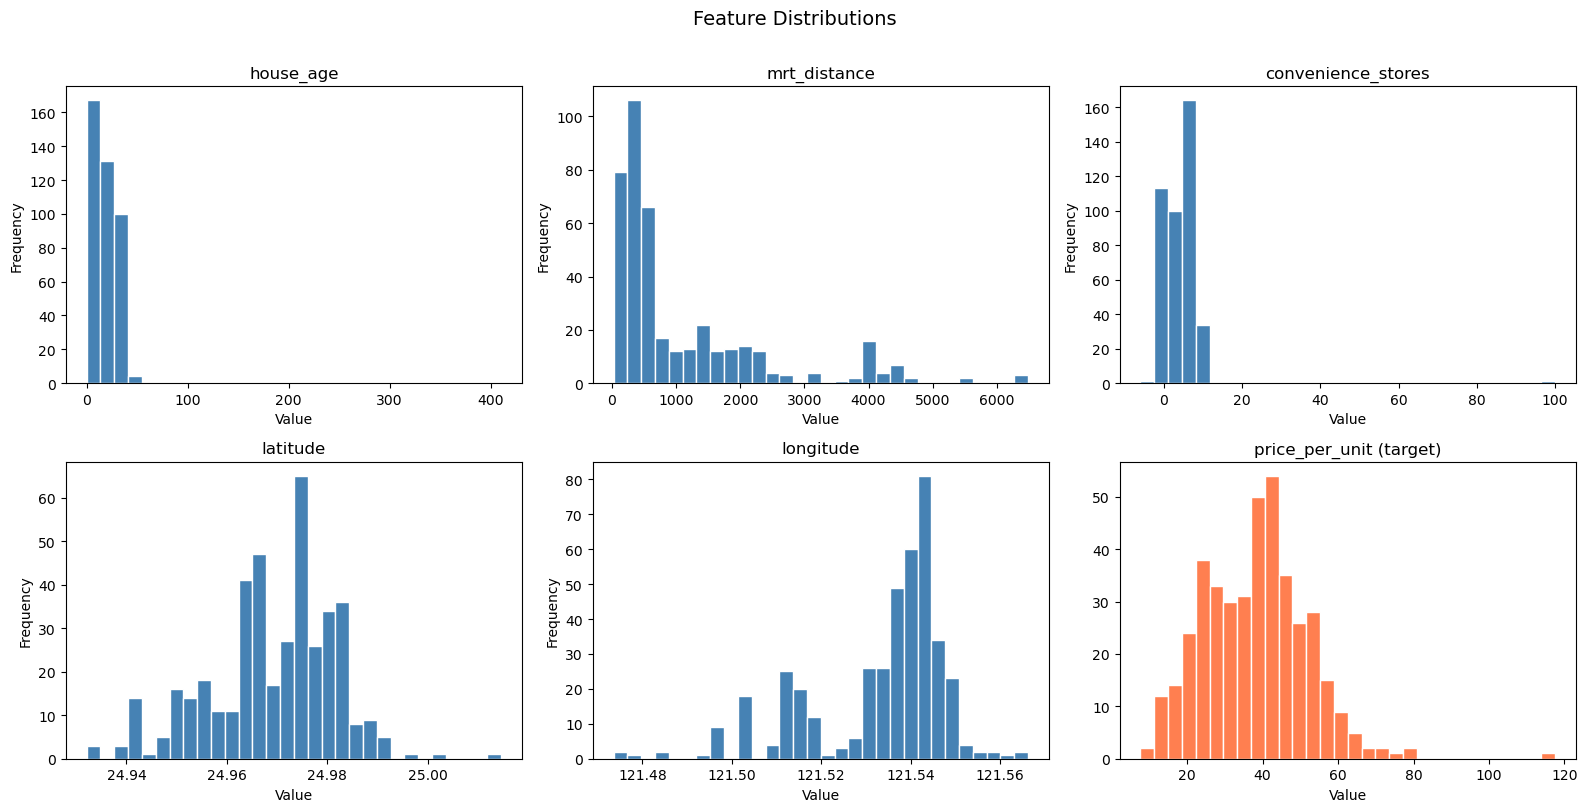

In [10]:
features = ['house_age', 'mrt_distance', 'convenience_stores', 'latitude', 'longitude']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].hist(df['price_per_unit'], bins=30, color='coral', edgecolor='white')
axes[-1].set_title('price_per_unit (target)')
axes[-1].set_xlabel('Value')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- house_age is right-skewed with most properties under 50 years, but that extreme tail stretching to 410 is immediately visible 
- mrt_distance is heavily right-skewed. Most properties sit under 1,000m from a station, but a long tail extends to 6,500m. 
    - **Potentially log transform**
- convenience_stores is concentrated between 0–10, with what appears to be a single extreme value near 100 
    - **worth investigating as a potential error.**
- latitude & longitude both look roughly normal and geographically clustered
    - **No major concerns here.**
- price_per_unit (target) is moderately right-skewed, centered around 35–40 with a tail toward 120. 
    - **Not severe enough to demand a log transform on the target, but worth noting.**

# Boxplots for outlier detection

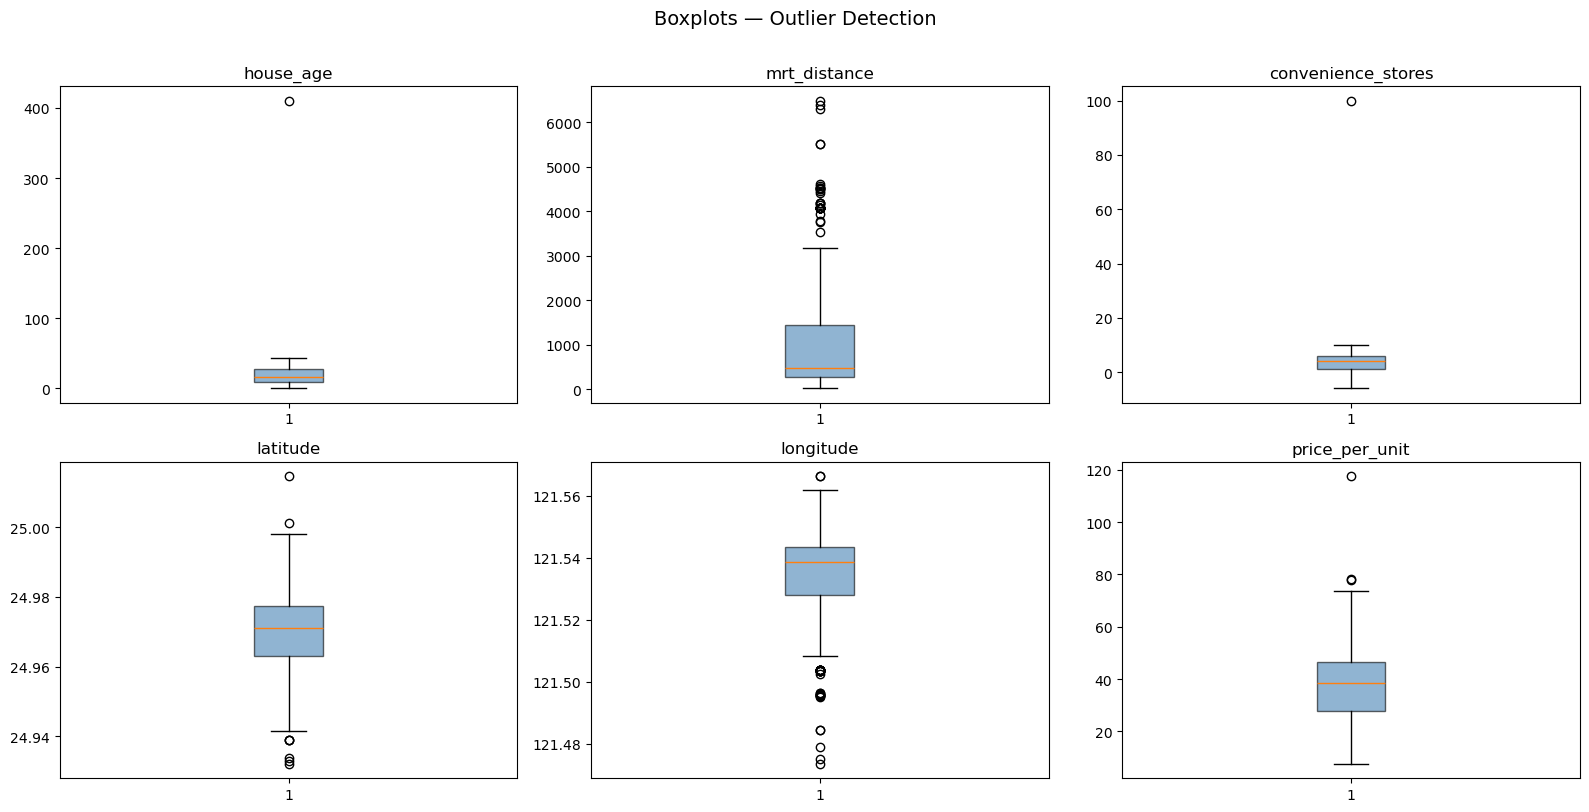

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

all_cols = ['house_age', 'mrt_distance', 'convenience_stores',
            'latitude', 'longitude', 'price_per_unit']

for i, col in enumerate(all_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- house_age has one extreme outlier well above 400
    - **almost certainly a data entry error.**-
- mrt_distance has a large cluster of outliers in the upper range, but these are likely real
- convenience_stores has a single point near 100, isolated far above the rest of the distribution. 
    - **warrants a closer look.**
- price_per_unit has a handful of high-end outliers around 78 and 117, but the IQR looks healthy. 
    - **These could be legitimate luxury properties.**

In [13]:
print("Max house_age:", df['house_age'].max())

df[df['house_age'] > 100]

Max house_age: 410.3


,house_age,mrt_distance,convenience_stores,latitude,longitude,price_per_unit
128,410.3,124.9912,6.0,24.96674,121.54039,60.7


Consider dropping this row

# Log transform skewed features

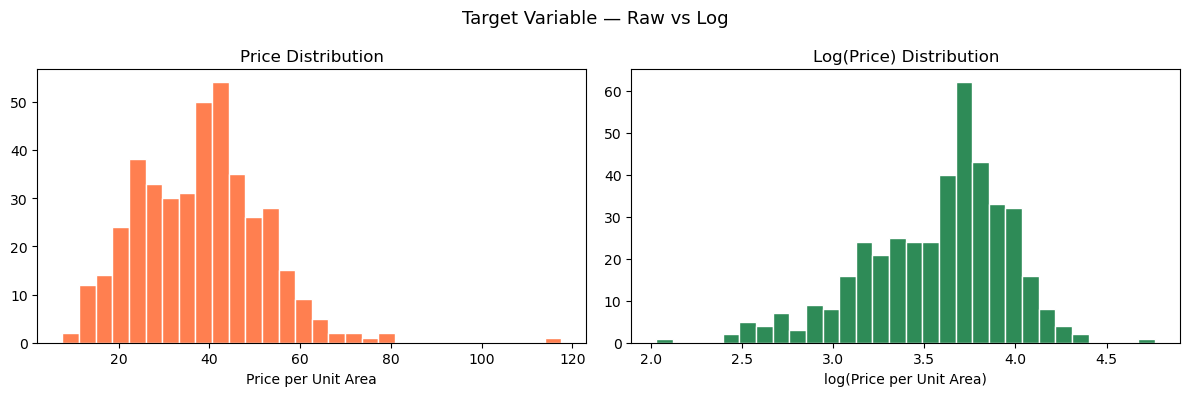

Skew (raw):  0.60
Skew (log):  -0.71


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_per_unit'], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price per Unit Area')

axes[1].hist(np.log(df['price_per_unit']), bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Log(Price) Distribution')
axes[1].set_xlabel('log(Price per Unit Area)')

plt.suptitle('Target Variable — Raw vs Log', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Skew (raw):  {df['price_per_unit'].skew():.2f}")
print(f"Skew (log):  {np.log(df['price_per_unit']).skew():.2f}")

We should probably keep the target as is

# Correlation heatmap

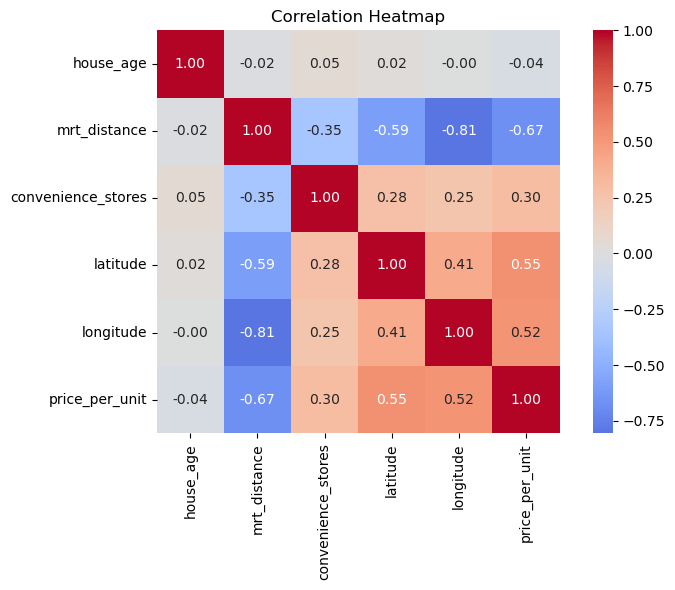

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

- mrt_distance is the strongest predictor at -0.67 with price  
    - **the further from an MRT station, the lower the price.**
- latitude (0.55) and longitude (0.52) both correlate meaningfully with price, confirming that location within the city matters independently of MRT access.
- mrt_distance and longitude are highly correlated (-0.81) — this is a multicollinearity red flag. The MRT network is concentrated in the eastern/central parts of Taipei, so these two features are capturing overlapping information. 
    - **potential red flag**
- mrt_distance and latitude (-0.59) show a similar concern.
    - **potential red flag**
- house_age is nearly uncorrelated with everything, including price (-0.04). It could be because the outlier (410 years) is distorting the relationship. After removing it and applying a log transform, the signal may strengthen.
- convenience_stores (0.30) has a modest positive relationship with price  
    - **more stores nearby, slightly higher prices**  likely a proxy for urban density.

# Geographic view

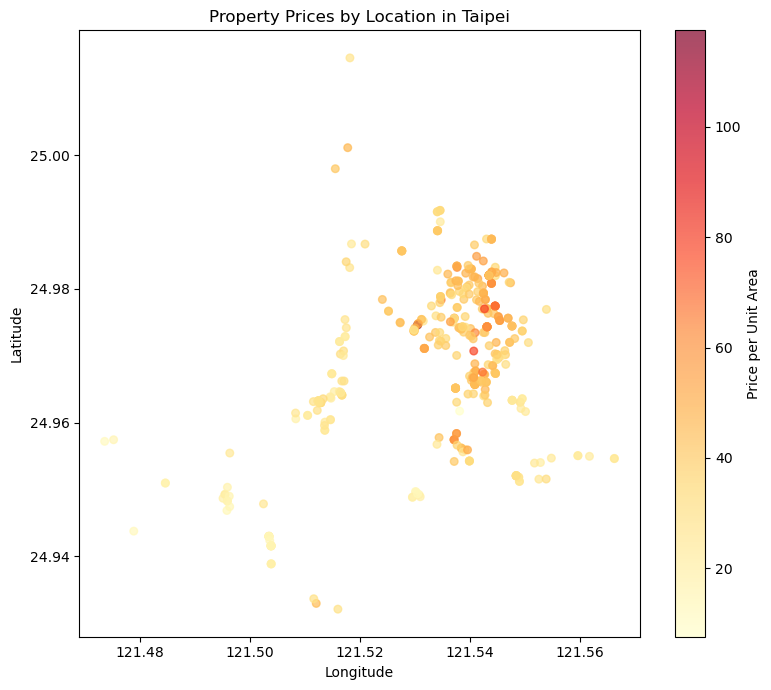

In [16]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['price_per_unit'],
    cmap='YlOrRd',
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label='Price per Unit Area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Property Prices by Location in Taipei')
plt.tight_layout()
plt.show()

The high-price cluster is tightly concentrated around longitude 121.53–121.54, latitude 24.97–24.98. After doing some research I found that this corresponds to the Xinyi/Daan district area which is Taipei's most desirable and expensive neighborhoods. The dark red dots are unmistakably clustered there.

Prices decay outward from that core. As you move west (lower longitude) or south (lower latitude), properties get progressively cheaper as the color fades from red/orange to pale yellow. 
The isolated dots in the periphery (far west around 121.47, far south around 24.93) are cheap and sparse which are likely suburban or less connected areas.

This validates keeping lat/lon as features, but it also raises an interesting modeling question: are latitude and longitude independently useful, or are they just a noisy proxy for MRT access? Given the heatmap showed mrt_distance correlates strongly with both, there's real overlap.

# Pairplot

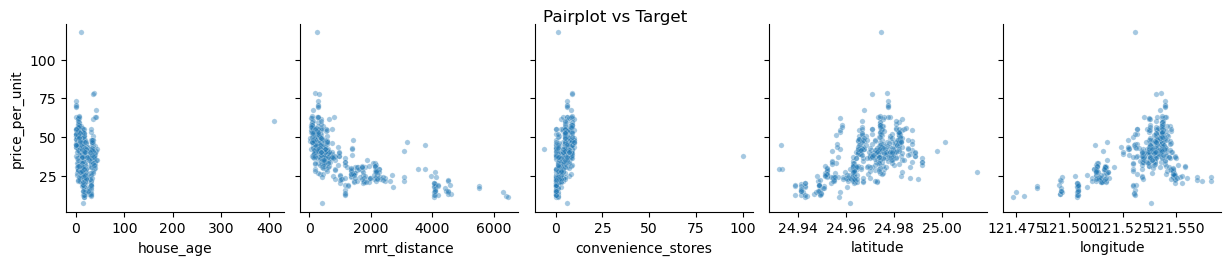

In [17]:
sns.pairplot(df, y_vars=['price_per_unit'], 
             x_vars=['house_age', 'mrt_distance', 'convenience_stores', 'latitude', 'longitude'],
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot vs Target', y=1.02)
plt.show()

house_age vs price shows almost no pattern essentially a vertical blob. This reinforces the near-zero correlation from the heatmap, and the 410-year outlier is clearly visible as an isolated dot far to the right with an unremarkable price. Good motivator for removing it.

mrt_distance vs price is the standout Price drops sharply as distance increases up to about 1,500m, then flattens out. This nonlinear shape is exactly why a log transform is warranted. A straight line would fit this relationship poorly; a line through log(distance) would fit it well.

convenience_stores vs price shows most data crammed at low values (0–10) with a weak positive trend. That single outlier near 100 stores is clearly visible as an isolated point.

latitude and longitude vs price both show a curved, non-uniform spread rather than a clean linear trend, which is consistent with what the map showed — price isn't uniformly changing across the city, it's clustering. This suggests these features will contribute to the model but may not behave perfectly linearly.